##Dependencies installation

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers accelerate datasets faiss-cpu \
    langchain langchain-community sentence-transformers \
    Pillow requests tqdm torch torchvision
!pip install -q bitsandbytes
!pip install -q bert-score
!pip install -q huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 25.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, 

##Imports and configuration

In [2]:
# Cell 2: Imports and config
import os, json, textwrap, re
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import faiss
from PIL import Image
from tqdm import tqdm

from transformers import (
    CLIPProcessor, CLIPModel,
    BitsAndBytesConfig,
    LlavaForConditionalGeneration,
    AutoProcessor,
)
from datasets import load_dataset
from huggingface_hub import snapshot_download

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

CLIP_MODEL = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

# ✅ CHANGED: LLaVA-1.5 actually reads your text prompt
GEN_MODEL  = "llava-hf/llava-1.5-7b-hf"

TOP_K      = 5
INDEX_PATH = "/content/slake_index.faiss"
META_PATH  = "/content/slake_meta.json"

print(f"Device    : {DEVICE}")
print(f"Encoder   : {CLIP_MODEL}")
print(f"Generator : {GEN_MODEL}")

Device    : cuda
Encoder   : microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
Generator : llava-hf/llava-1.5-7b-hf


##Dataset

Loading SLAKE metadata…


README.md:   0%|          | 0.00/568 [00:00<?, ?B/s]

train.json: 0.00B [00:00, ?B/s]

validation.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

...

Extracting to /content/slake_images…
Images ready at: /content/slake_images
Sample image files: ['xmlab504', 'xmlab223', 'xmlab580', 'xmlab185', 'xmlab329']

Filtering train split (English + loadable image)…


Train filter: 100%|██████████| 9835/9835 [00:13<00:00, 720.23it/s] 


Filtering val split…


Val filter: 100%|██████████| 2099/2099 [00:02<00:00, 713.22it/s]


Knowledge base  (train, EN, with image): 4918
Evaluation set  (val,   EN, with image): 1053

Question    : What modality is used to take this image?
Answer      : MRI
Answer type : OPEN
Content type: Modality
Modality    : MRI
Image name  : xmlab1/source.jpg
Image size  : (256, 256)


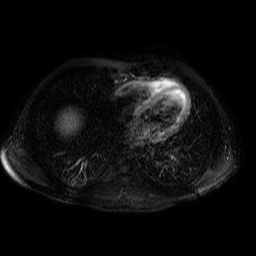

In [3]:
# Cell 3: Load SLAKE — fixed for actual HF dataset structure
# SLAKE on HF stores metadata only; images must be downloaded separately.

import os, zipfile
from huggingface_hub import hf_hub_download
from PIL import Image

print("Loading SLAKE metadata…")
slake       = load_dataset("BoKelvin/SLAKE")
train_split = slake["train"]
val_split   = slake["validation"]

print(f"Train samples : {len(train_split)}")
print(f"Val   samples : {len(val_split)}")
print(f"Features      : {list(train_split.features.keys())}")

# ── Step 1: Download the SLAKE images from HuggingFace repo ─────────────────
# Images live in the dataset repo as a zip file (imgs.zip)
SLAKE_IMG_DIR = "/content/slake_images"

if not os.path.exists(SLAKE_IMG_DIR):
    print("\nDownloading SLAKE images…")
    zip_path = hf_hub_download(
        repo_id  = "BoKelvin/SLAKE",
        filename = "imgs.zip",
        repo_type= "dataset",
    )
    print(f"Extracting to {SLAKE_IMG_DIR}…")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/")

    # After extraction the folder is typically /content/imgs — rename for clarity
    if os.path.exists("/content/imgs") and not os.path.exists(SLAKE_IMG_DIR):
        os.rename("/content/imgs", SLAKE_IMG_DIR)

    print(f"Images ready at: {SLAKE_IMG_DIR}")
else:
    print(f"Images already extracted at: {SLAKE_IMG_DIR}")

# Verify extraction
sample_files = os.listdir(SLAKE_IMG_DIR)[:5]
print(f"Sample image files: {sample_files}")

# ── Step 2: Helper to load image by img_name ─────────────────────────────────
def load_slake_image(img_name: str) -> Optional[Image.Image]:
    """Load a SLAKE image by its img_name field."""
    # Try direct path first
    path = os.path.join(SLAKE_IMG_DIR, img_name)
    if os.path.exists(path):
        return Image.open(path).convert("RGB")

    # Some entries use just the filename without subfolder
    basename = os.path.basename(img_name)
    for root, dirs, files in os.walk(SLAKE_IMG_DIR):
        if basename in files:
            return Image.open(os.path.join(root, basename)).convert("RGB")

    return None  # image not found

# ── Step 3: Filter — English only, image loadable, non-empty answer ──────────
def is_valid(sample):
    if sample.get("q_lang") != "en":
        return False
    if not str(sample.get("answer", "")).strip():
        return False
    if not str(sample.get("question", "")).strip():
        return False
    img = load_slake_image(sample.get("img_name", ""))
    return img is not None

print("\nFiltering train split (English + loadable image)…")
kb_samples   = [s for s in tqdm(train_split, desc="Train filter") if is_valid(s)]

print("Filtering val split…")
eval_samples = [s for s in tqdm(val_split,   desc="Val filter")   if is_valid(s)]

print(f"\nKnowledge base  (train, EN, with image): {len(kb_samples)}")
print(f"Evaluation set  (val,   EN, with image): {len(eval_samples)}")

# ── Step 4: Preview one sample ───────────────────────────────────────────────
s   = kb_samples[0]
img = load_slake_image(s["img_name"])

print(f"\nQuestion    : {s['question']}")
print(f"Answer      : {s['answer']}")
print(f"Answer type : {s.get('answer_type', 'N/A')}")
print(f"Content type: {s.get('content_type', 'N/A')}")
print(f"Modality    : {s.get('modality', 'N/A')}")   # X-ray / CT / MRI
print(f"Image name  : {s['img_name']}")
print(f"Image size  : {img.size}")
display(img)

##BiomedCLIP encoder (shared image + text embedding space)

In [4]:
# Cell 4: BiomedCLIP encoder
# BiomedCLIP is trained on 15M biomedical image-caption pairs from PubMed Central.
# It vastly outperforms generic CLIP on medical retrieval tasks.
#
# NOTE: BiomedCLIP uses open_clip under the hood.
!pip install -q open_clip_torch

import open_clip

print("Loading BiomedCLIP…")
biomedclip_model, _, biomedclip_preprocess = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
biomedclip_tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
biomedclip_model = biomedclip_model.to(DEVICE).eval()

DIM = 512   # BiomedCLIP output dimension

@torch.no_grad()
def embed_image(pil_img: Image.Image) -> np.ndarray:
    """Encode a PIL image to a unit-norm BiomedCLIP vector."""
    img_tensor = biomedclip_preprocess(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)
    vec = biomedclip_model.encode_image(img_tensor)
    vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec.cpu().numpy().astype("float32")

@torch.no_grad()
def embed_text(text: str) -> np.ndarray:
    """Encode a text string to a unit-norm BiomedCLIP vector."""
    tokens = biomedclip_tokenizer([text]).to(DEVICE)
    vec = biomedclip_model.encode_text(tokens)
    vec = vec / vec.norm(dim=-1, keepdim=True)
    return vec.cpu().numpy().astype("float32")

# Quick smoke test
test_vec = embed_text("chest X-ray showing pneumonia")
print(f"BiomedCLIP ready ✓  |  embedding dim: {test_vec.shape[-1]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
Loading BiomedCLIP…


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP ready ✓  |  embedding dim: 512


##Build the FAISS index (offline indexing)

In [5]:
# Cell 5: Build FAISS index over SLAKE knowledge base
# Each entry stores: question, answer, answer_type, content_type,
#                    body_part, image_organ, and the KBase explanation.

def build_slake_index(samples, index_path=INDEX_PATH, meta_path=META_PATH):
    index    = faiss.IndexFlatIP(DIM)   # cosine similarity (unit vectors)
    metadata = []

    for s in tqdm(samples, desc="Indexing SLAKE"):
        img = load_slake_image(s["img_name"])
        if img is None:
          continue   # skip if image missing

        # Fuse image + question text at index time for richer embeddings
        img_vec = embed_image(img)
        txt_vec = embed_text(s["question"])
        fused   = 0.6 * img_vec + 0.4 * txt_vec
        fused  /= np.linalg.norm(fused, axis=-1, keepdims=True)

        index.add(fused)

        # Build a rich context string from SLAKE's structured knowledge base
        kbase_str = ""
        if s.get("base") and isinstance(s["base"], dict):
            kbase_str = "; ".join(
                f"{k}: {v}" for k, v in s["base"].items()
                if v and str(v).strip()
            )[:400]

        metadata.append({
            "question"    : s["question"],
            "answer"      : str(s["answer"]),
            "answer_type" : s.get("answer_type", ""),    # OPEN / CLOSED
            "content_type": s.get("content_type", ""),   # Abnormality, Organ…
            "img_organ"   : s.get("img_organ", ""),      # e.g. "Chest", "Brain"
            "kbase"       : kbase_str,                   # structured knowledge
        })

    faiss.write_index(index, index_path)
    with open(meta_path, "w") as f:
        json.dump(metadata, f)

    print(f"Index saved → {index_path}  ({index.ntotal} vectors)")
    return index, metadata


# ── Build or load ────────────────────────────────────────────────────────────
if Path(INDEX_PATH).exists():
    print("Loading existing SLAKE index…")
    index    = faiss.read_index(INDEX_PATH)
    metadata = json.load(open(META_PATH))
    print(f"Loaded {index.ntotal} vectors")
else:
    index, metadata = build_slake_index(kb_samples)

Indexing SLAKE: 100%|██████████| 4918/4918 [03:02<00:00, 26.89it/s]

Index saved → /content/slake_index.faiss  (4918 vectors)


##Retriever (fused image + query)

In [6]:
# Cell 6: Retriever — identical fusion logic, SLAKE-aware field names

def retrieve(
    query_text : str,
    query_image: Optional[Image.Image] = None,
    top_k      : int = TOP_K,
    alpha      : float = 0.6,     # slightly image-heavy for radiology
) -> list[dict]:
    if query_image is not None and query_text:
        img_vec   = embed_image(query_image.convert("RGB"))
        txt_vec   = embed_text(query_text)
        query_vec = alpha * img_vec + (1 - alpha) * txt_vec
        query_vec /= np.linalg.norm(query_vec, axis=-1, keepdims=True)
    elif query_image is not None:
        query_vec = embed_image(query_image.convert("RGB"))
    else:
        query_vec = embed_text(query_text)

    distances, indices = index.search(query_vec, top_k)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx < 0:
            continue
        entry         = metadata[idx].copy()
        entry["score"] = float(dist)
        results.append(entry)

    return results


# ── Sanity check ─────────────────────────────────────────────────────────────
test_q = "Is there any abnormality in this chest X-ray?"
hits   = retrieve(test_q)
for h in hits[:2]:
    print(f"[{h['score']:.3f}] ({h['img_organ']}) {h['question']}")
    print(f"         Answer: {h['answer']}  |  Type: {h['content_type']}\n")

[0.711] () Is/Are there abnormalities in the patient's left lung?
         Answer: Yes  |  Type: Abnormality

[0.711] () Is/Are there abnormalities in the patient's right lung?
         Answer: No  |  Type: Abnormality



##Context builder (anti-hallucination prompt)

In [7]:
# Cell 7: Medical grounded prompt — concise, answer-encouraging

def build_medical_prompt(query_text: str, retrieved: list[dict]) -> str:
    """
    Builds a clean, concise prompt that encourages the model to answer
    from context rather than refusing. Top 3 results only to stay within
    the model's context window.
    """
    context_lines = []
    for i, r in enumerate(retrieved[:3], 1):
        organ  = r.get("img_organ", "N/A")
        ctype  = r.get("content_type", "N/A")
        kbase  = r.get("kbase", "")

        line = (
            f"[{i}] Related question : {r['question']}\n"
            f"     Known answer     : {r['answer']}\n"
            f"     Organ            : {organ} | Category: {ctype}\n"
        )
        if kbase:
            line += f"     Medical facts    : {kbase[:200]}\n"

        context_lines.append(line)

    context_str = "\n".join(context_lines)

    # ✅ CHANGED: No Rule 3 "say I don't know" — model is told to answer directly
    prompt = (
        "You are a medical AI assistant trained in radiology.\n"
        "Use the retrieved context below to answer the question.\n"
        "Give a concise, direct answer. "
        "If it is a yes/no question, answer Yes or No first.\n\n"
        "══ RETRIEVED CONTEXT ══\n"
        f"{context_str}\n"
        "══ QUESTION ══\n"
        f"{query_text}\n\n"
        "══ ANSWER ══\n"
    )

    return prompt

##Load the generative VQA model (BLIP-2)

In [8]:
# Cell 8: Load LLaVA-1.5-7B as the generative model
# ✅ CHANGED: LLaVA reads both image AND text prompt properly

print("Loading LLaVA-1.5-7B...")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,                       # 4-bit fits on T4 (16GB)
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

gen_processor = AutoProcessor.from_pretrained(GEN_MODEL)

gen_model = LlavaForConditionalGeneration.from_pretrained(
    GEN_MODEL,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
gen_model.eval()
print("LLaVA-1.5-7B ready ✓")

Loading LLaVA-1.5-7B...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA-1.5-7B ready ✓


##Full RAG inference pipeline

In [9]:
# Cell 9: End-to-end RAG inference — fixed for LLaVA + correct token decoding

def rag_answer(
    query_text    : str,
    query_image   : Optional[Image.Image] = None,
    top_k         : int   = TOP_K,
    alpha         : float = 0.5,
    max_new_tokens: int   = 128,
    verbose       : bool  = True,
) -> str:
    """
    Full multimodal RAG pipeline:
      1. Retrieve relevant context using fused BiomedCLIP embeddings
      2. Build a concise grounded prompt
      3. Generate an answer with LLaVA-1.5 conditioned on image + prompt
    """

    # ── Step 1: Retrieve ────────────────────────────────────────────────────
    retrieved = retrieve(query_text, query_image, top_k=top_k, alpha=alpha)
    if verbose:
        print(f"Retrieved {len(retrieved)} contexts "
              f"(top score: {retrieved[0]['score']:.3f})")

    # ── Step 2: Build prompt ─────────────────────────────────────────────────
    prompt = build_medical_prompt(query_text, retrieved)

    # ── Step 3: Format input for LLaVA ──────────────────────────────────────
    # LLaVA expects the prompt wrapped in its chat template with <image> token
    if query_image is not None:
        img_input = query_image.convert("RGB")
        # LLaVA-1.5 chat format: must include <image> token in the prompt
        llava_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"
    else:
        # No image — use a blank white image (LLaVA requires an image input)
        img_input = Image.new("RGB", (336, 336), color=(255, 255, 255))
        llava_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"

    inputs = gen_processor(
        images=img_input,
        text=llava_prompt,
        return_tensors="pt",
    ).to(gen_model.device)

    # ── Step 4: Generate ─────────────────────────────────────────────────────
    # ✅ FIXED: Record input length so we only decode NEW tokens
    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            length_penalty=1.0,
            early_stopping=True,
            no_repeat_ngram_size=3,
            temperature=0.3,          # lower = more factual, less creative
            do_sample=False,          # deterministic with beam search
        )

    # ✅ FIXED: Slice off input tokens — decode only what the model generated
    new_tokens = output_ids[0][input_length:]
    answer = gen_processor.decode(new_tokens, skip_special_tokens=True).strip()

    return answer

##LangChain wrapper (optional, clean interface)

In [10]:
# Cell 10: LangChain wrapper — wraps the RAG pipeline as a Chain

from langchain_core.runnables import RunnableLambda
from langchain_core.output_parsers import StrOutputParser

def langchain_rag_node(inputs: dict) -> dict:
    """
    LangChain-compatible node.
    inputs: {"text": str, "image": PIL.Image or None}
    """
    answer = rag_answer(
        query_text =inputs["text"],
        query_image=inputs.get("image"),
        verbose    =inputs.get("verbose", True),
    )
    return {"answer": answer, "query": inputs["text"]}

# Build the chain
rag_chain = (
    RunnableLambda(langchain_rag_node)
    | RunnableLambda(lambda x: x["answer"])
    | StrOutputParser()
)

print("LangChain RAG chain ready ✓")

LangChain RAG chain ready ✓


## Run demo queries

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


SECTION 1: CLOSED-ENDED (YES/NO) QUESTIONS
Retrieved 5 contexts (top score: 0.695)
[Closed-1] Q: Is there any abnormality visible in the lung area?
       A: Yes
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.748)
[Closed-2] Q: Is this a chest X-ray?
       A: Yes
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.722)
[Closed-3] Q: Is the liver visible in this image?
       A: Yes
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.630)
[Closed-4] Q: Are there any signs of fracture in the bone?
       A: No
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.762)
[Closed-5] Q: Is this image taken from an MRI scan?
       A: Yes
----------------------------------------------------------------------

SECTION 2: OPEN-ENDED ORGAN/STRUCTURE IDENTIFICATION (WITH IMAGE)


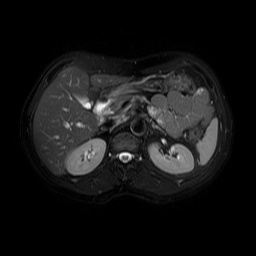

Retrieved 5 contexts (top score: 0.950)
[Open-1] Q: What organ is shown in this medical image?
       A: The organ shown in the medical image is the liver.
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.943)
[Open-2] Q: What body part is highlighted in the image?
       A: Abdomen
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.877)
[Open-3] Q: What type of scan is this?
       A: MRI
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.928)
[Open-4] Q: How many organs are visible in this image?
       A: 3
----------------------------------------------------------------------
Retrieved 5 contexts (top score: 0.879)
[Open-5] Q: What is the position of the abnormality?
       A: Yes
----------------------------------------------------------------------

Ground truth answer: MRI

SECTION 3: DESCRIPTIVE / DIAGNOSTIC QUEST

In [11]:
# Cell 11: Demo queries

from IPython.display import display

# ── helpers ──────────────────────────────────────────────────────────────────
def run_demo(tag, question, image=None):
    payload = {"text": question}
    if image is not None:
        payload["image"] = image
    ans = rag_chain.invoke(payload)
    print(f"[{tag}] Q: {question}")
    print(f"       A: {ans}")
    print("-" * 70)

# ── Demo 1 — Closed-ended (Yes/No) questions ─────────────────────────────────
print("=" * 70)
print("SECTION 1: CLOSED-ENDED (YES/NO) QUESTIONS")
print("=" * 70)

closed_questions = [
    "Is there any abnormality visible in the lung area?",
    "Is this a chest X-ray?",
    "Is the liver visible in this image?",
    "Are there any signs of fracture in the bone?",
    "Is this image taken from an MRI scan?"
]

for i, q in enumerate(closed_questions, 1):
    run_demo(f"Closed-{i}", q)

# ── Demo 2 — Open-ended organ/structure identification (with image) ───────────
print("\n" + "=" * 70)
print("SECTION 2: OPEN-ENDED ORGAN/STRUCTURE IDENTIFICATION (WITH IMAGE)")
print("=" * 70)

demo_sample = eval_samples[0]
demo_image  = load_slake_image(demo_sample["img_name"])   # fix: was s["img_name"]
display(demo_image)

open_questions = [
    "What organ is shown in this medical image?",
    "What body part is highlighted in the image?",
    "What type of scan is this?",
    "How many organs are visible in this image?",
    "What is the position of the abnormality?"
]

for i, q in enumerate(open_questions, 1):
    run_demo(f"Open-{i}", q, image=demo_image)

print(f"\nGround truth answer: {demo_sample['answer']}")

# ── Demo 3 — Descriptive / diagnostic questions (with image) ─────────────────
print("\n" + "=" * 70)
print("SECTION 3: DESCRIPTIVE / DIAGNOSTIC QUESTIONS (WITH IMAGE)")
print("=" * 70)

descriptive_questions = [
    "What abnormality is present in this image?",
    "Describe the condition visible in the scan.",
    "What is the color of the lesion shown?",
    "What is the size of the affected area?",
    "What does the bright region in the image indicate?"
]

for i, q in enumerate(descriptive_questions, 1):
    run_demo(f"Descriptive-{i}", q, image=demo_image)

# ── Demo 4 — Out-of-distribution / anti-hallucination tests ──────────────────
print("\n" + "=" * 70)
print("SECTION 4: OUT-OF-DISTRIBUTION (ANTI-HALLUCINATION) QUESTIONS")
print("Expected: system should return 'I don't know' or similar")
print("=" * 70)

ood_questions = [
    "What is the patient's age?",
    "What medication is the patient taking?",
    "What is the patient's blood pressure?",
    "What does the ECG reading show?",
    "What is the patient's diagnosis from the blood report?"
]

for i, q in enumerate(ood_questions, 1):
    run_demo(f"OOD-{i}", q)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DEMO COMPLETE")
print(f"Total questions tested : {len(closed_questions) + len(open_questions) + len(descriptive_questions) + len(ood_questions)}")
print(f"  Closed-ended         : {len(closed_questions)}")
print(f"  Open-ended           : {len(open_questions)}")
print(f"  Descriptive          : {len(descriptive_questions)}")
print(f"  Anti-hallucination   : {len(ood_questions)}")
print("=" * 70)

##Evaluation (hallucination metric with BERTScore)

In [12]:
# Cell 12: Evaluation — accuracy + grounding score on SLAKE eval set
!pip install -q bert-score

from bert_score import score as bert_score
import random

def evaluate_slake(n_closed=30, n_open=20):
    """
    Split evaluation by answer type (SLAKE's own taxonomy):
      - CLOSED: yes/no questions  → exact-match accuracy
      - OPEN  : factual questions → BERTScore grounding
    """
    closed = [s for s in eval_samples if s.get("answer_type") == "CLOSED"][:n_closed]
    open_  = [s for s in eval_samples if s.get("answer_type") == "OPEN"][:n_open]

    # ── CLOSED: exact-match accuracy ─────────────────────────────────────────
    correct = 0
    for s in tqdm(closed, desc="Closed QA"):
        pred = rag_answer(
            s["question"],
            query_image=load_slake_image(s["img_name"]),
            verbose=False,
        ).strip().lower()
        gt = str(s["answer"]).strip().lower()
        # Flexible match: pred contains the ground truth token
        if gt in pred or pred in gt:
            correct += 1

    closed_acc = correct / len(closed) if closed else 0
    print(f"\nClosed QA accuracy : {correct}/{len(closed)} = {closed_acc:.2%}")

    # ── OPEN: BERTScore grounding ─────────────────────────────────────────────
    refs, hyps = [], []
    for s in tqdm(open_, desc="Open QA"):
        pred = rag_answer(
            s["question"],
            query_image=load_slake_image(s["img_name"]),
            verbose=False,
        )
        refs.append(str(s["answer"]))
        hyps.append(pred)

    P, R, F1 = bert_score(hyps, refs, lang="en", verbose=False)
    print(f"Open QA BERTScore  : P={P.mean():.4f}  R={R.mean():.4f}  F1={F1.mean():.4f}")

    return closed_acc, F1.mean().item()

closed_acc, open_f1 = evaluate_slake()


Closed QA: 100%|██████████| 30/30 [01:39<00:00,  3.31s/it]



Closed QA accuracy : 29/30 = 96.67%



Open QA: 100%|██████████| 20/20 [01:13<00:00,  3.66s/it]


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Open QA BERTScore  : P=0.9545  R=0.9490  F1=0.9517


In [13]:
!pip install ipywidgets -q

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from PIL import Image  # if needed for your load_slake_image

# Assuming these are already defined in your notebook:
# rag_chain, eval_samples, load_slake_image

In [14]:
# ====================== MEDICAL IMAGE RAG DASHBOARD ======================

from IPython.display import display, clear_output
import ipywidgets as widgets

# ── Helper to run a single query ─────────────────────────────────────
def run_query(question, image=None):
    payload = {"text": question}
    if image is not None:
        payload["image"] = image
    try:
        ans = rag_chain.invoke(payload)
        return ans
    except Exception as e:
        return f"Error: {str(e)}"

# ── Create Dashboard ─────────────────────────────────────────────────
print("🚀 Building Medical Image RAG Dashboard...")

# Tabs
tab = widgets.Tab()

# Section 1: Closed-ended Questions
closed_questions = [
    "Is there any abnormality visible in the lung area?",
    "Is this a chest X-ray?",
    "Is the liver visible in this image?",
    "Are there any signs of fracture in the bone?",
    "Is this image taken from an MRI scan?"
]

closed_output = widgets.Output()

def run_closed_demo(b):
    with closed_output:
        clear_output()
        print("="*80)
        print("SECTION 1: CLOSED-ENDED (YES/NO) QUESTIONS")
        print("="*80)
        for i, q in enumerate(closed_questions, 1):
            ans = run_query(q)
            print(f"Closed-{i} | Q: {q}")
            print(f"       A: {ans}")
            print("-" * 70)

closed_btn = widgets.Button(description="Run All Closed Questions", button_style='info')
closed_btn.on_click(run_closed_demo)

closed_box = widgets.VBox([closed_btn, closed_output])

# Section 2 & 3: Image-based Questions (Open + Descriptive)
image_output = widgets.Output()
query_output = widgets.Output()

# Dropdown to choose sample image
sample_options = [(f"Sample {i+1}: {s.get('img_name','')}", i) for i, s in enumerate(eval_samples)]
image_dropdown = widgets.Dropdown(
    options=sample_options,
    description='Select Image:',
    style={'description_width': 'initial'}
)

def load_and_show_image(change=None):
    idx = image_dropdown.value
    demo_sample = eval_samples[idx]
    demo_image = load_slake_image(demo_sample["img_name"])

    with image_output:
        clear_output()
        display(HTML("<h3>Selected Medical Image</h3>"))
        display(demo_image)
        print(f"Ground Truth Answer: {demo_sample.get('answer', 'N/A')}")

image_dropdown.observe(load_and_show_image, names='value')

# Question input + button
question_input = widgets.Textarea(
    value="What organ is shown in this medical image?",
    placeholder="Type your question here...",
    description='Question:',
    layout=widgets.Layout(width='90%', height='80px')
)

run_btn = widgets.Button(description="🚀 Run Query on Current Image", button_style='success', layout=widgets.Layout(width='auto'))

def on_run_query(b):
    idx = image_dropdown.value
    demo_image = load_slake_image(eval_samples[idx]["img_name"])

    with query_output:
        clear_output()
        print(f"🔍 Query: {question_input.value}")
        ans = run_query(question_input.value, demo_image)
        print(f"✅ Answer: {ans}")

run_btn.on_click(on_run_query)

# Predefined Open + Descriptive questions as buttons
open_q = ["What organ is shown in this medical image?",
          "What body part is highlighted in the image?",
          "What type of scan is this?",
          "How many organs are visible in this image?"]

desc_q = ["What abnormality is present in this image?",
          "Describe the condition visible in the scan.",
          "What does the bright region indicate?"]

def create_quick_buttons(questions, title):
    buttons = []
    for q in questions:
        btn = widgets.Button(description=q[:40] + "..." if len(q)>40 else q,
                            button_style='primary', layout=widgets.Layout(width='auto'))
        def make_handler(qq):
            def handler(b):
                question_input.value = qq
                on_run_query(None)
            return handler
        btn.on_click(make_handler(q))
        buttons.append(btn)
    return widgets.VBox([widgets.HTML(f"<b>{title}</b>"), widgets.HBox(buttons)])

quick_open = create_quick_buttons(open_q, "Quick Open-ended Questions")
quick_desc = create_quick_buttons(desc_q, "Quick Descriptive Questions")

image_tab_content = widgets.VBox([
    image_dropdown,
    image_output,
    widgets.HBox([question_input, run_btn]),
    quick_open,
    quick_desc,
    query_output
])

# Section 4: Anti-Hallucination (OOD) Tests
ood_questions = [
    "What is the patient's age?",
    "What medication is the patient taking?",
    "What is the patient's blood pressure?",
    "What does the ECG reading show?",
    "What is the patient's diagnosis from the blood report?"
]

ood_output = widgets.Output()

def run_ood_demo(b):
    with ood_output:
        clear_output()
        print("="*80)
        print("SECTION 4: OUT-OF-DISTRIBUTION (ANTI-HALLUCINATION) TESTS")
        print("Expected: 'I don't know' or similar")
        print("="*80)
        for i, q in enumerate(ood_questions, 1):
            ans = run_query(q)   # no image
            print(f"OOD-{i} | Q: {q}")
            print(f"       A: {ans}")
            print("-" * 70)

ood_btn = widgets.Button(description="Run Anti-Hallucination Tests", button_style='warning')
ood_btn.on_click(run_ood_demo)

ood_box = widgets.VBox([ood_btn, ood_output])

# Put everything into tabs
tab.children = [
    closed_box,
    image_tab_content,
    ood_box
]

tab.set_title(0, 'Closed-ended (Yes/No)')
tab.set_title(1, 'Image-based QA (Open + Descriptive)')
tab.set_title(2, 'Anti-Hallucination Tests')

# Header
header = widgets.HTML("""
<h2 style="color: #2E86C1;">🩺 Medical Image RAG System Dashboard</h2>
<p>Select tabs below to test different types of queries on your RAG chain.</p>
<hr>
""")

dashboard = widgets.VBox([header, tab])

# Show the dashboard
display(dashboard)

# Load first image by default
load_and_show_image()

🚀 Building Medical Image RAG Dashboard...
